In [1]:
savecache=1
loadcache=0

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [3]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [4]:
expts=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"]
expts.index('historical')

2

In [5]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "1pctCO2", "historical","ssp585", "ssp245","ssp126"], flds = flds, dbe=['CMIP','CMIP','CMIP','CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
# 'ACCESS-ESM1-5',
models=['CanESM5']


Getting some data that can be used by the forcer engine and ciceroscm

In [6]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp126","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

Getting training data to use for predictions:

In [7]:
if not loadcache:
    test_data={}
    for m in models:
        print(m)
        test_data[m] = {

            "base": data_getter.make_meteor_training_data("base", m), #control simulation
            "co2x4": data_getter.make_meteor_training_data("co2x4", m), #co2 only response
            "1pc": data_getter.make_meteor_training_data("1pc", m)} #co2 only response
            
        for s in scenarios:
                test_data[m][s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], m
                    )


CanESM5


In [8]:
if savecache:
    cachedir = os.path.join(os.getcwd(), "cache")
    if not os.path.exists(cachedir):
        os.makedirs(cachedir)
    for m in models:
        for k in test_data[m]:
            test_data[m][k].to_netcdf(
                os.path.join(cachedir, f"{m}_{k}_test_data.nc")
            )

In [9]:
if loadcache:
    cachedir = os.path.join(os.getcwd(), "cache")

    test_data={}
    for m in models:
        test_data[m] = {
            "base": xr.open_dataset(
                os.path.join(cachedir, f"{m}_base_test_data.nc")
            ),
            "co2x4": xr.open_dataset(
                os.path.join(cachedir, f"{m}_co2x4_test_data.nc")
            ),
            "1pc": xr.open_dataset(
                os.path.join(cachedir, f"{m}_1pc_test_data.nc")
            ),
        }
        for s in scenarios:
            test_data[m][s] = xr.open_dataset(
                os.path.join(cachedir, f"{m}_{s}_test_data.nc")
            )
        
        

Let's use SSP245 as the anomaly experiment

In [10]:
test_data[m]["sulxanom"]=test_data[m]["ssp245"]

Making patterns one with just co2x4, and one including the sulfate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

First encode the pure CO2 response

In [11]:
%%capture
ghg_pattern = {}
for m in models:
    ghg_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-ghg",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )

Now encode a set of patterns, including the historical/future composite

In [12]:
%%capture
anomsulf_pattern = {}
for m in models:
    anomsulf_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-anomsulf",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

Then taking the data from the ssp-data for ciceroscm and making predictions

In [13]:
%%capture
patterns_ghg={}
patterns_anomsulf={}
for m in models:
    patterns_ghg[m]={}
    patterns_anomsulf[m]={}

    for i,s in enumerate(scenarios):
        patterns_ghg[m][s]=(ghg_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )
        patterns_anomsulf[m][s]=(anomsulf_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

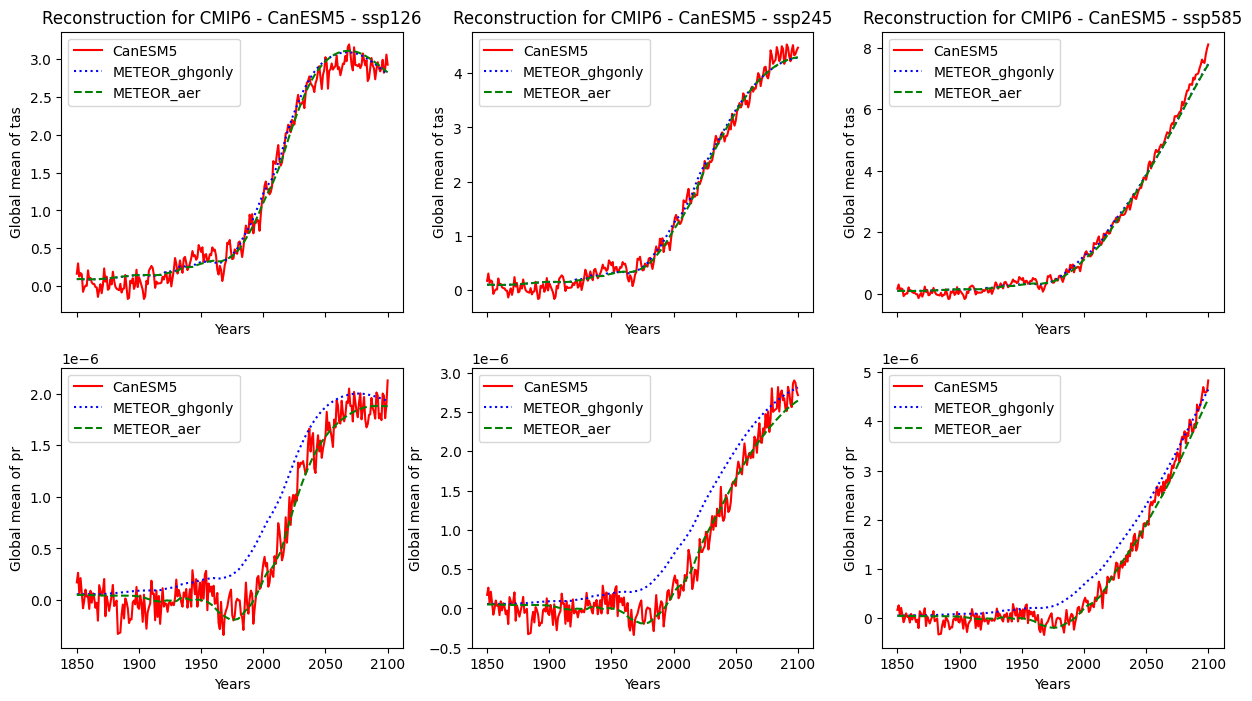

In [14]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=len(scenarios), sharex=True,figsize=(15,8))
m="CanESM5"
for i,s in enumerate(scenarios):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(test_data[m]["base"][fld]).values)
        total_years = len(test_data[m]["sulxanom"][fld]["year"].values)
        years_to_plot = range(1850,1850+total_years)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(test_data[m][s][fld]).values[0,:]-zero_val, color="red", label=m)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_ghg[m][s][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[m][s][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Reconstruction for CMIP6 - "+m+" - "+s)
        axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[j,i].legend()